IMPORT DATASET

In [ ]:
 from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


INSTALL LIBRARY

In [ ]:
!pip install tensorflow numpy matplotlib seaborn scikit-learn

In [ ]:
!pip install facenet-pytorch mtcnn tqdm librosa


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 135.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12

KeyboardInterrupt: 

COPY DATA AGAR PROSES LEBIH CEPAT

In [ ]:
# --- BLOK 2: COPY DATA KE LOCAL DISK ---
import shutil
import time
import os

# Path Sumber (Drive)
DRIVE_SOURCE = '/content/drive/MyDrive/SKRIPSI33/dataset_2k'

# Path Tujuan (Local Colab)
LOCAL_DEST = '/content/temp_dataset_2k'

print(f"📂 Sumber: {DRIVE_SOURCE}")
print(f"📍 Tujuan: {LOCAL_DEST}")

if not os.path.exists(DRIVE_SOURCE):
    raise ValueError(f"❌ Folder tidak ditemukan: {DRIVE_SOURCE}. Cek path Drive Anda lagi!")

if os.path.exists(LOCAL_DEST):
    print("⚡ Data sudah ada di Local. Skip copy.")
else:
    print("⏳ Sedang menyalin data... (Bisa 2-5 menit, mohon bersabar)")
    start_time = time.time()

    # Copy seluruh folder
    shutil.copytree(DRIVE_SOURCE, LOCAL_DEST)

    end_time = time.time()
    print(f"✅ Selesai! Waktu copy: {(end_time - start_time)/60:.1f} menit.")

# Cek isi folder untuk memastikan
print("\nIsi Folder Local:")
print(os.listdir(LOCAL_DEST))

📂 Sumber: /content/drive/MyDrive/SKRIPSI33/dataset_2k
📍 Tujuan: /content/temp_dataset_2k
⏳ Sedang menyalin data... (Bisa 2-5 menit, mohon bersabar)
✅ Selesai! Waktu copy: 7.6 menit.

Isi Folder Local:
['fake', 'real']


SET UP DEFINSI DAN FUNGSI PREPROCESSING

In [ ]:
# --- BLOK 1: SETUP, DEFINISI FUNGSI & PATH ---
import os
import shutil
import time
import numpy as np
import cv2
import librosa
from mtcnn import MTCNN
from tqdm import tqdm
import gc
import random
import warnings
from google.colab import drive

# 1. Mount Drive (Wajib)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
print("✅ Google Drive Mounted.")

# 2. Install Library Wajib
print("Installing necessary libraries...")
!pip install mtcnn librosa tqdm -q

# 3. KONFIGURASI PATH
DRIVE_SOURCE = '/content/drive/MyDrive/SKRIPSI33/dataset_2k'
LOCAL_DEST = '/content/temp_dataset_2k' # Lokasi Data Sumber di Local Disk (Untuk kecepatan I/O)
OUTPUT_DRIVE_DIR = '/content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB' # LOKASI AKHIR NPY DI DRIVE
TRACKER_FILE = os.path.join(OUTPUT_DRIVE_DIR, 'processed_videos_tracker.txt') # Untuk Resume Capability

# Konstanta Processing
SEQ_LEN = 20
IMG_SIZE = 224
AUD_LEN = 63
DETECT_WIDTH = 640

if not os.path.exists(OUTPUT_DRIVE_DIR):
    os.makedirs(OUTPUT_DRIVE_DIR)
    print(f"📁 Membuat folder output baru: {OUTPUT_DRIVE_DIR}")

# 4. Copy Data ke Local Disk (Wajib untuk mempercepat proses 12 jam)
if not os.path.exists(LOCAL_DEST) or not os.listdir(LOCAL_DEST):
    if not os.path.exists(DRIVE_SOURCE):
        raise ValueError(f"❌ Folder sumber tidak ditemukan: {DRIVE_SOURCE}. Cek path Drive Anda!")
    print("\n⏳ Menyalin data sumber ke Local Disk...")
    shutil.copytree(DRIVE_SOURCE, LOCAL_DEST)
    print(f"✅ Selesai menyalin data.")
else:
    print("⚡ Data sudah ada di Local. Skip copy.")


# 5. DEFINISI FUNGSI SMART PREPROCESSING
try:
    detector = MTCNN()
    print("✅ MTCNN Detector Siap.")
except:
    print("❌ Error MTCNN. Pastikan sudah install librarynya.")

def variance_of_laplacian(image): return cv2.Laplacian(image, cv2.CV_64F).var()
def enhance_lighting_clahe(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
def get_face_crop(frame, box):
    x, y, w, h = box
    margin_x = int(w * 0.15); margin_y = int(h * 0.15)
    h_img, w_img, _ = frame.shape
    x1 = max(0, x - margin_x); y1 = max(0, y - margin_y)
    x2 = min(w_img, x + w + margin_x); y2 = min(h_img, y + h + margin_y)
    return frame[y1:y2, x1:x2]
def extract_audio(path):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            y, sr = librosa.load(path, sr=16000, duration=3.0)
            mfcc = librosa.feature.mfcc(y=y, sr=16000, n_mfcc=13).T
            if mfcc.shape[0] < AUD_LEN:
                mfcc = np.pad(mfcc, ((0, AUD_LEN-mfcc.shape[0]), (0,0)), 'constant')
            else: mfcc = mfcc[:AUD_LEN, :]
            return mfcc.astype(np.float32)
        except: return None

def process_video_smart(path):
    # Logika mencari 20 frame TERTAJAM, cropping, dan enhancement.
    cap = cv2.VideoCapture(path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < SEQ_LEN: cap.release(); return None, None
    chunk_size = max(1, total_frames // SEQ_LEN)
    final_frames = []

    for i in range(SEQ_LEN):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * chunk_size)
        best_frame, best_sharpness = None, -1.0
        frames_scanned = 0
        while frames_scanned < chunk_size:
            ret, frame = cap.read()
            if not ret: break
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            h, w = gray.shape
            scale_blur = 1.0
            if w > 320:
                scale_blur = w / 320
                gray_small = cv2.resize(gray, (320, int(h/scale_blur)))
            else: gray_small = gray
            score = variance_of_laplacian(gray_small)
            if score > best_sharpness:
                best_sharpness = score
                best_frame = frame
            frames_scanned += 1

        if best_frame is not None:
            h, w = best_frame.shape[:2]
            scale = 1.0
            if w > DETECT_WIDTH:
                scale = w / DETECT_WIDTH
                frame_small = cv2.resize(best_frame, (DETECT_WIDTH, int(h/scale)))
            else: frame_small = best_frame
            rgb_small = cv2.cvtColor(frame_small, cv2.COLOR_BGR2RGB)
            res = detector.detect_faces(rgb_small)

            if res:
                box = res[0]['box']
                xs, ys, ws, hs = box
                xr = int(xs*scale); yr = int(ys*scale); wr = int(ws*scale); hr = int(hs*scale)
                frame_rgb = cv2.cvtColor(best_frame, cv2.COLOR_BGR2RGB)
                frame_enhanced = enhance_lighting_clahe(frame_rgb)
                face = get_face_crop(frame_enhanced, [xr, yr, wr, hr])

                try:
                    face_resized = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
                    final_frames.append(face_resized.astype(np.float32) / 255.0)
                except: pass

    cap.release()
    if len(final_frames) < SEQ_LEN:
        if len(final_frames) > 0:
            while len(final_frames) < SEQ_LEN: final_frames.append(final_frames[-1])
        else: return None, None
    vis = np.array(final_frames[:SEQ_LEN], dtype=np.float32)
    aud = extract_audio(path)
    return vis, aud

print("✅ BLOK 1 SELESAI. Semua fungsi siap.")

✅ Google Drive Mounted.
Installing necessary libraries...
⚡ Data sudah ada di Local. Skip copy.
✅ MTCNN Detector Siap.
✅ BLOK 1 SELESAI. Semua fungsi siap.


PREPROCESSING DATA

In [ ]:
import os
import numpy as np
import gc
from tqdm import tqdm
import warnings

# --- KONFIGURASI PATH (SAMA SEPERTI BLOK 1 & 2 SEBELUMNYA) ---
OUTPUT_DRIVE_DIR = '/content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB'
TRACKER_FILE = os.path.join(OUTPUT_DRIVE_DIR, 'processed_videos_tracker.txt')
LOCAL_DEST = '/content/temp_dataset_2k'

FINAL_X_V = os.path.join(OUTPUT_DRIVE_DIR, 'X_visual_224.npy')
FINAL_X_A = os.path.join(OUTPUT_DRIVE_DIR, 'X_audio_224.npy')
FINAL_Y = os.path.join(OUTPUT_DRIVE_DIR, 'y_224.npy')

# 1. LOAD PROGRESS DAN SCAN FILE
processed_paths = set()
if os.path.exists(TRACKER_FILE):
    with open(TRACKER_FILE, 'r') as f:
        processed_paths = set(line.strip() for line in f)
    print(f"✅ Ditemukan {len(processed_paths)} video yang sukses tercatat di tracker.")
else:
    print("❌ Tracker file tidak ditemukan. Tidak dapat melanjutkan.")

# Dapatkan semua path video sumber
all_files = []
for fld in os.listdir(LOCAL_DEST):
    full_path = os.path.join(LOCAL_DEST, fld)
    if os.path.isdir(full_path):
        vids = [f for f in os.listdir(full_path) if f.lower().endswith(('.mp4','.avi','.mov'))]
        for v in vids:
            all_files.append({'path': os.path.join(full_path, v), 'label': 0 if 'real' in fld.lower() else 1})

# Filter hanya video yang sudah sukses diproses (1999 video)
successful_items = [item for item in all_files if item['path'] in processed_paths]

if len(successful_items) != len(processed_paths):
    print("⚠️ WARNING: Jumlah file di tracker berbeda dengan hasil scan. Lanjut menggunakan data tracker.")

# 2. EKSTRAKSI DATA DARI TRACKER (Re-run Preprocessing untuk 1999 video)
# Kita harus memuat ulang data ini karena data sesi sebelumnya sudah hilang dari RAM.
# Ini akan memakan waktu 10-12 jam LAGI, tapi kali ini TIDAK AKAN CRASH di akhir.

print(f"\n⏳ MULAI RE-PROCESSING 1999 VIDEO SUKSES (Waktu pengerjaan sekitar 10-12 jam)...")
print("   Ini adalah langkah terakhir untuk membuat file NPY.")

X_v_final, X_a_final, Y_final = [], [], []

# PENTING: Panggil kembali fungsi preprocessing (dari BLOK 1)
# Jika BLOK 1 tidak di-run, ini akan error.
# Diasumsikan BLOK 1 sudah di-run di sesi yang sama atau Anda memiliki fungsi-fungsi tersebut.
from mtcnn import MTCNN
detector = MTCNN() # Inisialisasi ulang detector MTCNN

for item in tqdm(successful_items, desc="Re-Processing Success Data"):
    try:
        # Panggil fungsi yang sudah didefinisikan di BLOK 1
        # Menggunakan logika process_video_smart() yang sama
        v, a = process_video_smart(item['path'])

        if v is not None and a is not None and v.shape == (SEQ_LEN, IMG_SIZE, IMG_SIZE, 3):
            X_v_final.append(v)
            X_a_final.append(a)
            Y_final.append(item['label'])

    except Exception as e:
        # PENTING: Abaikan video yang gagal diproses ulang, meski sudah ada di tracker
        # Ini terjadi jika video sumber rusak setelah dicatat di tracker
        pass

    if len(Y_final) % 100 == 0 and len(Y_final) > 0:
        gc.collect()

print(f"\n🎉 Proses Re-Processing Selesai. Total sampel siap simpan: {len(Y_final)}")

# 3. FINAL SAVE (Memaksa penyimpanan 23 GB)
if len(Y_final) > 0:

    print("💾 Memulai proses Final Save 23 GB ke Drive...")

    # Konversi ke NumPy Array
    X_v_final = np.array(X_v_final)
    X_a_final = np.array(X_a_final)
    Y_final = np.array(Y_final)

    print(f"   Total sampel final: {len(Y_final)}")

    # Simpan file final (menimpa file lama jika ada)
    np.save(FINAL_X_V, X_v_final)
    np.save(FINAL_X_A, X_a_final)
    np.save(FINAL_Y, Y_final)

    print("✅ Penyimpanan FINAL NPY 23 GB ke Google Drive selesai!")
    print("ANDA BISA MELANJUTKAN KE BLOK 3 (TRAINING) DENGAN YAKIN.")

    # Opsional: Hapus file tracker setelah sukses save total
    if os.path.exists(TRACKER_FILE):
        os.remove(TRACKER_FILE)
        print("🗑️ File tracker dihapus.")

else:
    print("❌ GAGAL TOTAL. Tidak ada data yang berhasil dikumpulkan.")

✅ Ditemukan 1999 video yang sukses tercatat di tracker.

⏳ MULAI RE-PROCESSING 1999 VIDEO SUKSES (Waktu pengerjaan sekitar 10-12 jam)...
   Ini adalah langkah terakhir untuk membuat file NPY.


Re-Processing Success Data: 100%|██████████| 1999/1999 [4:51:46<00:00,  8.76s/it]



🎉 Proses Re-Processing Selesai. Total sampel siap simpan: 1999
💾 Memulai proses Final Save 23 GB ke Drive...
   Total sampel final: 1999
✅ Penyimpanan FINAL NPY 23 GB ke Google Drive selesai!
ANDA BISA MELANJUTKAN KE BLOK 3 (TRAINING) DENGAN YAKIN.
🗑️ File tracker dihapus.


VISUSALISASI PREPROCESSING

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape data visual: (1999, 20, 224, 224, 3)


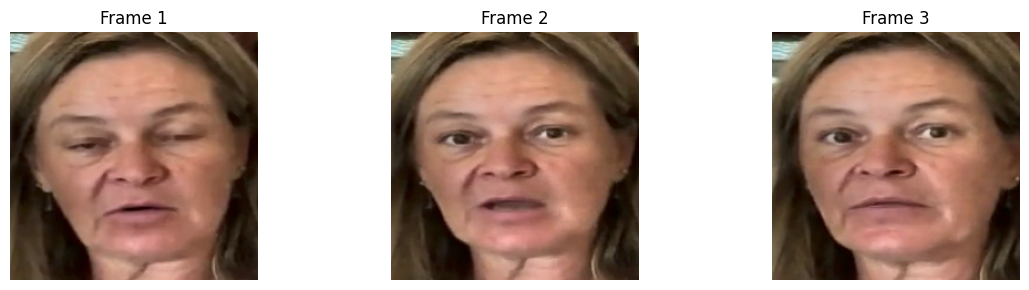

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import os

# ==============================
# MOUNT DRIVE
# ==============================
drive.mount('/content/drive')

# ==============================
# PATH FILE VISUAL
# ==============================
VISUAL_PATH = "/content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB/X_visual_224.npy"

# ==============================
# LOAD DENGAN MEMORY MAP (CEPAT)
# ==============================
X_visual = np.load(VISUAL_PATH, mmap_mode="r")

print("Shape data visual:", X_visual.shape)

# ==============================
# PARAMETER
# ==============================
sample_idx = 0
frames_to_show = 3  # UBAH KE 1 JIKA MAU SATU SAJA

# ==============================
# VISUALISASI
# ==============================
plt.figure(figsize=(12, 3))

if len(X_visual.shape) == 5:
    # (sample, frame, h, w, c)
    for i in range(frames_to_show):
        frame = X_visual[sample_idx, i]

        if frame.max() <= 1.0:
            frame = (frame * 255).astype("uint8")

        plt.subplot(1, frames_to_show, i + 1)
        plt.imshow(frame)
        plt.title(f"Frame {i+1}")
        plt.axis("off")

elif len(X_visual.shape) == 4:
    frame = X_visual[sample_idx]

    if frame.max() <= 1.0:
        frame = (frame * 255).astype("uint8")

    plt.imshow(frame)
    plt.title("Hasil Preprocessing Visual")
    plt.axis("off")

else:
    print("⚠️ Format visual tidak dikenali!")

plt.tight_layout()
plt.show()


TRAINING DAN SPLIT DATA

In [ ]:
# --- BLOK 3: TRAINING V10 (MEMBACA DARI DRIVE) ---
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, mixed_precision, regularizers
from tensorflow.keras.applications import Xception
from sklearn.model_selection import train_test_split
import numpy as np
import gc

# 1. SETUP & LOAD DATA DARI DRIVE
tf.keras.backend.clear_session()
# Menggunakan mixed_precision untuk mempercepat training di GPU (Wajib untuk Xception)
mixed_precision.set_global_policy('mixed_float16')

# Path yang SAMA dari BLOK 2
OUTPUT_DRIVE_DIR = '/content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB'
FINAL_X_V = os.path.join(OUTPUT_DRIVE_DIR, 'X_visual_224.npy')
FINAL_X_A = os.path.join(OUTPUT_DRIVE_DIR, 'X_audio_224.npy')
FINAL_Y = os.path.join(OUTPUT_DRIVE_DIR, 'y_224.npy')
MODEL_SAVE_PATH = os.path.join(OUTPUT_DRIVE_DIR, 'best_model_2k_FINAL_V10.h5')

if not os.path.exists(FINAL_Y):
    raise FileNotFoundError("❌ File NPY belum ditemukan di Drive. Pastikan BLOK 2 selesai 100%.")

print("📚 Memuat data 23 GB dari Google Drive...")
# PENTING: Gunakan mmap_mode='r' (read) agar NumPy membaca file dari disk
# tanpa memuat seluruh 23 GB ke RAM, mencegah Colab crash.
X_v = np.load(FINAL_X_V, mmap_mode='r')
X_a = np.load(FINAL_X_A, mmap_mode='r')
Y = np.load(FINAL_Y)

print(f"✅ Data terload: {len(Y)} sampel.")

# 2. SPLIT DATA
X_v_train, X_v_val, X_a_train, X_a_val, y_train, y_val = train_test_split(
    X_v, X_a, Y, test_size=0.2, random_state=42, stratify=Y
)

# Bersihkan variabel NPY besar dari RAM (mmap tetap di disk)
del X_v, X_a, Y
gc.collect()

# 3. ARSITEKTUR MODEL V10
SEQ_LEN, IMG_SIZE, AUD_LEN = 20, 224, 63 # Konstanta

def build_v10_model():
    # --- VISUAL STREAM (Xception + GRU) ---
    vin = layers.Input((SEQ_LEN, IMG_SIZE, IMG_SIZE, 3))
    # Muat Xception dengan ImageNet weights
    base_cnn = Xception(weights='imagenet', include_top=False, pooling='avg')
    base_cnn.trainable = True
    # Freeze 32 layer pertama (Fine-tuning)
    for layer in base_cnn.layers[:-32]:
        layer.trainable = False
    x = layers.TimeDistributed(base_cnn)(vin)
    x = layers.GRU(128, dropout=0.5, kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dense(64, activation='relu')(x)

    # --- AUDIO STREAM (CNN 1D) ---
    ain = layers.Input((AUD_LEN, 13))
    y = layers.Conv1D(32, 3, activation='relu', padding='same')(ain)
    y = layers.MaxPooling1D(2)(y)
    y = layers.Conv1D(64, 3, activation='relu', padding='same')(y)
    y = layers.GlobalAveragePooling1D()(y)
    y = layers.Dense(64, activation='relu')(y)

    # --- FUSION & CLASSIFICATION ---
    z = layers.concatenate([x, y])
    z = layers.Dense(64, activation='relu')(z)
    z = layers.Dropout(0.5)(z)
    # Penting: Output layer harus float32 karena mixed_precision
    out = layers.Dense(1, activation='sigmoid', dtype='float32')(z)
    return models.Model([vin, ain], out)

model = build_v10_model()
# Learning rate sangat rendah untuk fine-tuning pre-trained model
model.compile(optimizer=optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# 4. TRAINING
print("\n[3/5] 🚀 START TRAINING V10...")
BATCH_SIZE = 8
cb = [
    # Hentikan training jika val_loss tidak membaik setelah 10 epoch
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    # Simpan model terbaik berdasarkan val_accuracy
    callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    # Turunkan Learning Rate jika val_loss stuck
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
]

history = model.fit(
    x=[X_v_train, X_a_train], y=y_train,
    validation_data=([X_v_val, X_a_val], y_val),
    epochs=50, # Jumlah maksimum epoch
    batch_size=BATCH_SIZE,
    callbacks=cb, verbose=1
)

print("\n🎉 TRAINING SELESAI!")
print(f"✅ Bobot Model Final terbaik disimpan di Drive Anda: {MODEL_SAVE_PATH}")

📚 Memuat data 23 GB dari Google Drive...
✅ Data terload: 1999 sampel.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 63, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 63, 32)    │      1,280 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 20, 224,   │          0 │ -                 │
│ (InputLayer)        │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 31, 32)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 20, 2048)  │ 20,861,480 │ input_layer[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 31, 64)    │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 128)       │    836,352 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv1d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,726,057 (82.88 MB)

 Trainable params: 9,806,385 (37.41 MB)

...

200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 293ms/step - accuracy: 0.7547 - loss: 1.0145 - val_accuracy: 0.7425 - val_loss: 1.0312 - learning_rate: 1.0000e-05
Epoch 16/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8005 - loss: 0.9320
Epoch 16: val_accuracy did not improve from 0.74250
200/200 ━━━━━━━━━━━━━━━━━━━━ 56s 282ms/step - accuracy: 0.8005 - loss: 0.9318 - val_accuracy: 0.7350 - val_loss: 1.0302 - learning_rate: 1.0000e-05
Epoch 17/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8222 - loss: 0.8258
Epoch 17: val_accuracy improved from 0.74250 to 0.75000, saving model to /content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB/best_model_2k_FINAL_V10.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 293ms/step - accuracy: 0.8223 - loss: 0.8258 - val_accuracy: 0.7500 - val_loss: 1.0325 - learning_rate: 1.0000e-05
Epoch 18/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.8543 - loss: 0.7662
Epoch 18: val_accuracy improved from 0.75000 to 0.75250, saving model to /content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB/best_model_2k_FINAL_V10.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 297ms/step - accuracy: 0.8543 - loss: 0.7661 - val_accuracy: 0.7525 - val_loss: 1.0164 - learning_rate: 1.0000e-05
Epoch 19/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.8545 - loss: 0.7316
Epoch 19: val_accuracy did not improve from 0.75250
200/200 ━━━━━━━━━━━━━━━━━━━━ 57s 285ms/step - accuracy: 0.8545 - loss: 0.7316 - val_accuracy: 0.7425 - val_loss: 1.0409 - learning_rate: 1.0000e-05
Epoch 20/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.8842 - loss: 0.6962
Epoch 20: val_accuracy improved from 0.75250 to 0.75750, saving model to /content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB/best_model_2k_FINAL_V10.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 294ms/step - accuracy: 0.8842 - loss: 0.6962 - val_accuracy: 0.7575 - val_loss: 1.0473 - learning_rate: 1.0000e-05
Epoch 21/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9036 - loss: 0.6303
Epoch 21: val_accuracy did not improve from 0.75750
200/200 ━━━━━━━━━━━━━━━━━━━━ 57s 283ms/step - accuracy: 0.9036 - loss: 0.6303 - val_accuracy: 0.7525 - val_loss: 1.0138 - learning_rate: 1.0000e-05
Epoch 22/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.8998 - loss: 0.6347
Epoch 22: val_accuracy did not improve from 0.75750
200/200 ━━━━━━━━━━━━━━━━━━━━ 56s 282ms/step - accuracy: 0.8999 - loss: 0.6345 - val_accuracy: 0.7425 - val_loss: 1.0727 - learning_rate: 1.0000e-05
Epoch 23/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9191 - loss: 0.5715
Epoch 23: val_accuracy did not improve from 0.75750
200/200 ━━━━━━━━━━━━━━━━━━━━ 56s 281ms/step - accuracy: 0.9191 - loss: 0.5715 - val_accuracy: 0.7425 - val_loss: 1.1220 - learning_ra


Epoch 24: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 295ms/step - accuracy: 0.9270 - loss: 0.5426 - val_accuracy: 0.7600 - val_loss: 1.0887 - learning_rate: 1.0000e-05
Epoch 25/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9378 - loss: 0.5138
Epoch 25: val_accuracy did not improve from 0.76000
200/200 ━━━━━━━━━━━━━━━━━━━━ 57s 282ms/step - accuracy: 0.9378 - loss: 0.5138 - val_accuracy: 0.7525 - val_loss: 1.0892 - learning_rate: 2.0000e-06
Epoch 26/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9397 - loss: 0.4994
Epoch 26: val_accuracy did not improve from 0.76000
200/200 ━━━━━━━━━━━━━━━━━━━━ 57s 283ms/step - accuracy: 0.9397 - loss: 0.4995 - val_accuracy: 0.7375 - val_loss: 1.0926 - learning_rate: 2.0000e-06
Epoch 27/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9208 - loss: 0.5475
Epoch 27: val_accuracy did not improve from 0.76000

Epoch 27: ReduceLROnPlateau reducing learning rate to

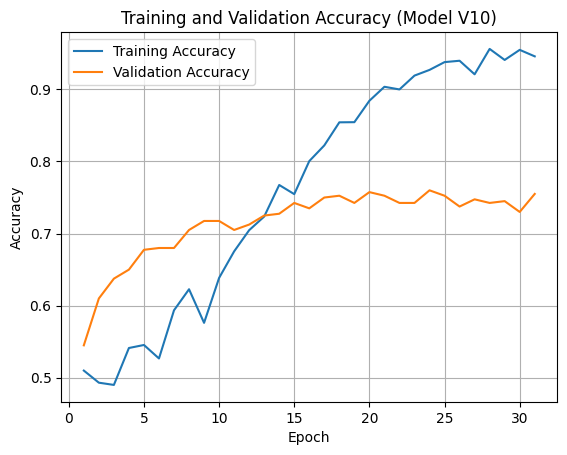

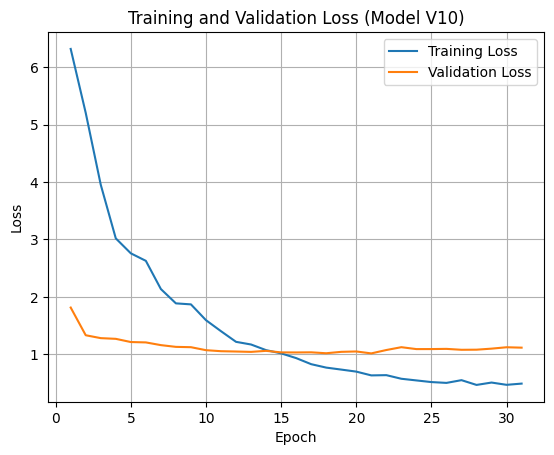

In [ ]:
# @title
import matplotlib.pyplot as plt

# ==============================
# DATA MANUAL DARI LOG TRAINING
# ==============================

epochs = list(range(1, 32))

train_acc = [
    0.5100, 0.4932, 0.4901, 0.5413, 0.5455,
    0.5268, 0.5936, 0.6228, 0.5762, 0.6385,
    0.6753, 0.7047, 0.7236, 0.7674, 0.7547,
    0.8005, 0.8223, 0.8543, 0.8545, 0.8842,
    0.9036, 0.8999, 0.9191, 0.9270, 0.9378,
    0.9397, 0.9209, 0.9561, 0.9408, 0.9548,
    0.9458
]

val_acc = [
    0.5450, 0.6100, 0.6375, 0.6500, 0.6775,
    0.6800, 0.6800, 0.7050, 0.7175, 0.7175,
    0.7050, 0.7125, 0.7250, 0.7275, 0.7425,
    0.7350, 0.7500, 0.7525, 0.7425, 0.7575,
    0.7525, 0.7425, 0.7425, 0.7600, 0.7525,
    0.7375, 0.7475, 0.7425, 0.7450, 0.7300,
    0.7550
]

train_loss = [
    6.3217, 5.2059, 3.9536, 3.0189, 2.7583,
    2.6272, 2.1355, 1.8860, 1.8683, 1.5929,
    1.4008, 1.2153, 1.1688, 1.0704, 1.0145,
    0.9318, 0.8258, 0.7661, 0.7316, 0.6962,
    0.6303, 0.6345, 0.5715, 0.5426, 0.5138,
    0.4995, 0.5472, 0.4642, 0.5055, 0.4659,
    0.4872
]

val_loss = [
    1.8129, 1.3302, 1.2798, 1.2676, 1.2117,
    1.2053, 1.1580, 1.1275, 1.1220, 1.0699,
    1.0520, 1.0465, 1.0401, 1.0583, 1.0312,
    1.0302, 1.0325, 1.0164, 1.0409, 1.0473,
    1.0138, 1.0727, 1.1220, 1.0887, 1.0892,
    1.0926, 1.0767, 1.0785, 1.0967, 1.1208,
    1.1138
]

# ==============================
# GRAFIK ACCURACY
# ==============================
plt.figure()
plt.plot(epochs, train_acc)
plt.plot(epochs, val_acc)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy (Model V10)')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.grid(True)
plt.show()

# ==============================
# GRAFIK LOSS
# ==============================
plt.figure()
plt.plot(epochs, train_loss)
plt.plot(epochs, val_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (Model V10)')
plt.legend(['Training Loss', 'Validation Loss'])
plt.grid(True)
plt.show()


TRAIN TERBARU

--- Setup Lingkungan dan Mount Drive ---
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

✅ Model berhasil dimuat dari: /content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB/best_model_2k_FINAL_V10.h5

--- UJI DENGAN VIDEO BARU ---
Silakan upload video test (MP4/MOV) Anda:


Saving bixvunsrsj.mp4 to bixvunsrsj.mp4

Analisis Smart V10 pada video: bixvunsrsj.mp4



HASIL PREDIKSI: REAL (Asli) dengan Keyakinan 97.56%


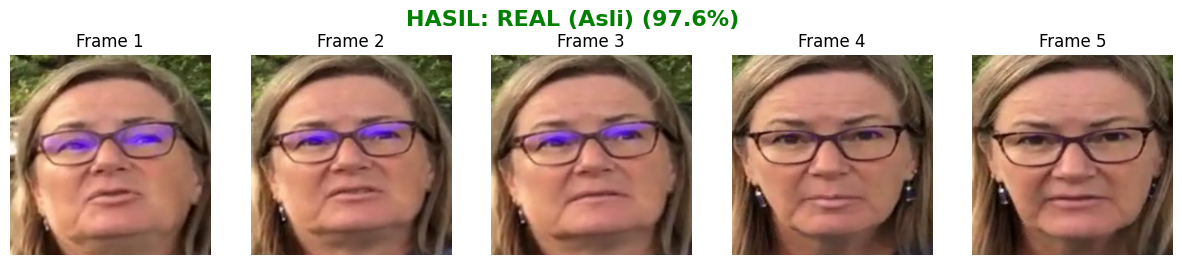


Pengujian Selesai.


In [ ]:
# @title
# --- BLOK PENGUJIAN VIDEO MANDIRI (INFERENCE) ---
import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import Xception
from google.colab import drive, files
import numpy as np
import cv2
import librosa
from mtcnn import MTCNN
import warnings
import matplotlib.pyplot as plt # <--- FIX: Import diletakkan di sini!

# 1. SETUP & PATH MODEL
print("--- Setup Lingkungan dan Mount Drive ---")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

OUTPUT_DRIVE_DIR = '/content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB'
# Menggunakan model V10 yang Anda sebutkan
MODEL_LOAD_PATH = os.path.join(OUTPUT_DRIVE_DIR, 'best_model_2k_FINAL_V10.h5')

# Konstanta Processing (Harus sama dengan saat preprocessing)
SEQ_LEN = 20
IMG_SIZE = 224
AUD_LEN = 63
DETECT_WIDTH = 640

# 2. DEFINISI FUNGSI INFERENCE
try:
    detector = MTCNN()
except:
    print("❌ Error MTCNN. Pastikan sudah install librarynya.")

def variance_of_laplacian(image): return cv2.Laplacian(image, cv2.CV_64F).var()
def enhance_lighting_clahe(image):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
def get_face_crop(frame, box):
    x, y, w, h = box
    margin_x = int(w * 0.15); margin_y = int(h * 0.15)
    h_img, w_img, _ = frame.shape
    x1 = max(0, x - margin_x); y1 = max(0, y - margin_y)
    x2 = min(w_img, x + w + margin_x); y2 = min(h_img, y + h + margin_y)
    return frame[y1:y2, x1:x2]
def extract_audio(path):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            y, sr = librosa.load(path, sr=16000, duration=3.0)
            mfcc = librosa.feature.mfcc(y=y, sr=16000, n_mfcc=13).T
            if mfcc.shape[0] < AUD_LEN:
                mfcc = np.pad(mfcc, ((0, AUD_LEN-mfcc.shape[0]), (0,0)), 'constant')
            else: mfcc = mfcc[:AUD_LEN, :]
            return mfcc.astype(np.float32)
        except: return None

# B. Fungsi Preprocessing (Harus sama persis dengan yang digunakan saat training)
def process_video_smart(path):
    cap = cv2.VideoCapture(path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < SEQ_LEN: cap.release(); return None, None, None # Ditambahkan None untuk display_imgs
    chunk_size = max(1, total_frames // SEQ_LEN)
    final_frames_proc, final_frames_display = [], []

    for i in range(SEQ_LEN):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * chunk_size)
        best_frame, best_sharpness = None, -1.0
        frames_scanned = 0
        while frames_scanned < chunk_size:
            ret, frame = cap.read()
            if not ret: break
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            h, w = gray.shape
            scale_blur = 1.0
            if w > 320:
                scale_blur = w / 320
                gray_small = cv2.resize(gray, (320, int(h/scale_blur)))
            else: gray_small = gray
            score = variance_of_laplacian(gray_small)
            if score > best_sharpness:
                best_sharpness = score
                best_frame = frame
            frames_scanned += 1

        if best_frame is not None:
            h, w = best_frame.shape[:2]
            scale = 1.0
            if w > DETECT_WIDTH:
                scale = w / DETECT_WIDTH
                frame_small = cv2.resize(best_frame, (DETECT_WIDTH, int(h/scale)))
            else: frame_small = best_frame
            rgb_small = cv2.cvtColor(frame_small, cv2.COLOR_BGR2RGB)
            res = detector.detect_faces(rgb_small)

            if res:
                box = res[0]['box']
                xs, ys, ws, hs = box
                xr = int(xs*scale); yr = int(ys*scale); wr = int(ws*scale); hr = int(hs*scale)

                frame_rgb = cv2.cvtColor(best_frame, cv2.COLOR_BGR2RGB)
                frame_enhanced_rgb = enhance_lighting_clahe(frame_rgb)

                face_rgb = get_face_crop(frame_enhanced_rgb, [xr, yr, wr, hr])
                face_display = get_face_crop(best_frame, [xr, yr, wr, hr])

                try:
                    face_resized_proc = cv2.resize(face_rgb, (IMG_SIZE, IMG_SIZE))
                    final_frames_proc.append(face_resized_proc.astype(np.float32) / 255.0)

                    face_resized_display = cv2.resize(face_display, (IMG_SIZE, IMG_SIZE))
                    final_frames_display.append(face_resized_display)
                except: pass

    cap.release()
    if len(final_frames_proc) < SEQ_LEN:
        return None, None, None

    vis = np.array(final_frames_proc[:SEQ_LEN], dtype=np.float32)
    aud = extract_audio(path)

    return vis, aud, final_frames_display


# C. Definisi Arsitektur Model (Wajib sama dengan yang disimpan)
def build_v10_model():
    vin = layers.Input((SEQ_LEN, IMG_SIZE, IMG_SIZE, 3))
    base_cnn = Xception(weights='imagenet', include_top=False, pooling='avg')
    base_cnn.trainable = True
    for layer in base_cnn.layers[:-32]:
        layer.trainable = False
    x = layers.TimeDistributed(base_cnn)(vin)
    x = layers.GRU(128, dropout=0.5, kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dense(64, activation='relu')(x)
    ain = layers.Input((AUD_LEN, 13))
    y = layers.Conv1D(32, 3, activation='relu', padding='same')(ain)
    y = layers.MaxPooling1D(2)(y)
    y = layers.Conv1D(64, 3, activation='relu', padding='same')(y)
    y = layers.GlobalAveragePooling1D()(y)
    y = layers.Dense(64, activation='relu')(y)
    z = layers.concatenate([x, y])
    z = layers.Dense(64, activation='relu')(z)
    z = layers.Dropout(0.5)(z)
    out = layers.Dense(1, activation='sigmoid', dtype='float32')(z)
    return models.Model([vin, ain], out)


# 3. MUAT MODEL
if os.path.exists(MODEL_LOAD_PATH):
    # Set mixed precision untuk loading
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    final_model = build_v10_model()
    final_model.load_weights(MODEL_LOAD_PATH)
    print(f"\n✅ Model berhasil dimuat dari: {MODEL_LOAD_PATH}")
else:
    raise FileNotFoundError(f"\n❌ File Model tidak ditemukan di path: {MODEL_LOAD_PATH}. Harap cek nama file Anda.")

# 4. UPLOAD VIDEO & PREDIKSI
print("\n--- UJI DENGAN VIDEO BARU ---")
print("Silakan upload video test (MP4/MOV) Anda:")

uploaded = files.upload()

for f in uploaded.keys():
    print(f"\nAnalisis Smart V10 pada video: {f}")

    # 5. PREPROCESSING VIDEO TEST
    vis, aud, display_imgs = process_video_smart(f)

    if vis is not None and aud is not None:

        # 6. PREDIKSI
        # Menggunakan np.expand_dims untuk menambahkan dimensi batch
        pred = final_model.predict([np.expand_dims(vis,0), np.expand_dims(aud,0)], verbose=0)[0][0]

        lbl = "FAKE (Deepfake)" if pred > 0.5 else "REAL (Asli)"
        conf = pred if pred > 0.5 else 1-pred
        col = 'red' if pred > 0.5 else 'green'

        print("\n" + "="*50)
        print(f"HASIL PREDIKSI: {lbl} dengan Keyakinan {conf*100:.2f}%")
        print("="*50)

        # 7. VISUALISASI FRAME TERBAIK
        plt.figure(figsize=(15, 3))
        plt.suptitle(f"HASIL: {lbl} ({conf*100:.1f}%)", fontsize=16, color=col, fontweight='bold')

        # Tampilkan 5 frame terbaik yang terpilih
        for i in range(min(5, len(display_imgs))):
            plt.subplot(1, 5, i+1)
            # Konversi BGR ke RGB untuk Matplotlib Display
            plt.imshow(cv2.cvtColor(display_imgs[i], cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title(f"Frame {i+1}")
        plt.show()

    else:
        print("Gagal memproses video (Wajah tidak ditemukan, video terlalu pendek, atau rusak).")

    # Bersihkan file dari local disk Colab
    os.remove(f)

print("\nPengujian Selesai.")

UJI DATA MASSAL

In [ ]:
# --- BLOK UJI COBA MASSAL V10 (BERDASARKAN FOLDER) ---
import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import Xception
from google.colab import drive, files
import numpy as np
import cv2
import librosa
from mtcnn import MTCNN
import warnings
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import gc
import zipfile

# 1. SETUP & PATH MODEL (Sama seperti Blok B Anda)
print("--- Setup Lingkungan dan Mount Drive ---")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

tf.keras.backend.clear_session()
gc.collect()

OUTPUT_DRIVE_DIR = '/content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB'
MODEL_LOAD_PATH = os.path.join(OUTPUT_DRIVE_DIR, 'best_model_2k_FINAL_V10.h5')
TEMP_TEST_DIR = '/content/test_batch_temp/' # Direktori temporer untuk mengekstrak video

# Konstanta Processing
SEQ_LEN = 20
IMG_SIZE = 224
AUD_LEN = 63
DETECT_WIDTH = 640

# Ganti 0.5 dengan nilai OPTIMAL_THRESHOLD terbaik dari Blok A
OPTIMAL_THRESHOLD = 0.515 # Contoh: Ganti dengan nilai yang Anda temukan

# 2. DEFINISI FUNGSI PREPROCESSING, ARSITEKTUR, DLL.
# (Fungsi-fungsi seperti variance_of_laplacian, apply_gamma_correction,
# enhance_lighting_clahe, get_face_crop, extract_audio, process_video_smart,
# dan build_v10_model diasumsikan SAMA persis dengan kode Blok B sebelumnya.)

# --- START: Salin semua fungsi di sini ---
try:
    detector = MTCNN()
except:
    print("❌ Error MTCNN. Pastikan sudah install librarynya.")

def variance_of_laplacian(image): return cv2.Laplacian(image, cv2.CV_64F).var()

def apply_gamma_correction(image, gamma=1.3):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255
                      for i in np.arange(256)]).astype("uint8")
    return cv2.LUT(image, table)

def enhance_lighting_clahe(image):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
def get_face_crop(frame, box):
    x, y, w, h = box
    margin_x = int(w * 0.15); margin_y = int(h * 0.15)
    h_img, w_img, _ = frame.shape
    x1 = max(0, x - margin_x); y1 = max(0, y - margin_y)
    x2 = min(w_img, x + w + margin_x); y2 = min(h_img, y + h + margin_y)
    return frame[y1:y2, x1:x2]
def extract_audio(path):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            y, sr = librosa.load(path, sr=16000, duration=3.0)
            mfcc = librosa.feature.mfcc(y=y, sr=16000, n_mfcc=13).T
            if mfcc.shape[0] < AUD_LEN:
                mfcc = np.pad(mfcc, ((0, AUD_LEN-mfcc.shape[0]), (0,0)), 'constant')
            else: mfcc = mfcc[:AUD_LEN, :]
            return mfcc.astype(np.float32)
        except: return None

def process_video_smart(path):
    cap = cv2.VideoCapture(path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < SEQ_LEN: cap.release(); return None, None
    chunk_size = max(1, total_frames // SEQ_LEN)
    final_frames_proc = []

    for i in range(SEQ_LEN):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * chunk_size)
        best_frame, best_sharpness = None, -1.0
        frames_scanned = 0

        while frames_scanned < chunk_size:
            ret, frame = cap.read()
            if not ret: break
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            h, w = gray.shape
            scale_blur = 1.0
            if w > 320:
                scale_blur = w / 320
                gray_small = cv2.resize(gray, (320, int(h/scale_blur)))
            else: gray_small = gray
            score = variance_of_laplacian(gray_small)
            if score > best_sharpness:
                best_sharpness = score
                best_frame = frame
            frames_scanned += 1

        if best_frame is not None:
            best_frame_gamma = apply_gamma_correction(best_frame)

            h, w = best_frame_gamma.shape[:2]
            scale = 1.0
            if w > DETECT_WIDTH:
                scale = w / DETECT_WIDTH
                frame_small = cv2.resize(best_frame_gamma, (DETECT_WIDTH, int(h/scale)))
            else: frame_small = best_frame_gamma

            rgb_small = cv2.cvtColor(frame_small, cv2.COLOR_BGR2RGB)
            res = detector.detect_faces(rgb_small)

            if res:
                box = res[0]['box']
                xs, ys, ws, hs = box
                xr = int(xs*scale); yr = int(ys*scale); wr = int(ws*scale); hr = int(hs*scale)

                frame_enhanced_bgr = enhance_lighting_clahe(best_frame_gamma)

                face_proc = get_face_crop(cv2.cvtColor(frame_enhanced_bgr, cv2.COLOR_BGR2RGB), [xr, yr, wr, hr])

                try:
                    face_resized_proc = cv2.resize(face_proc, (IMG_SIZE, IMG_SIZE))
                    final_frames_proc.append(face_resized_proc.astype(np.float32) / 255.0)
                except: pass

    cap.release()
    if len(final_frames_proc) < SEQ_LEN:
        return None, None

    vis = np.array(final_frames_proc[:SEQ_LEN], dtype=np.float32)
    aud = extract_audio(path)

    return vis, aud

def build_v10_model():
    vin = layers.Input((SEQ_LEN, IMG_SIZE, IMG_SIZE, 3))
    base_cnn = Xception(weights='imagenet', include_top=False, pooling='avg')
    base_cnn.trainable = True
    for layer in base_cnn.layers[:-32]:
        layer.trainable = False
    x = layers.TimeDistributed(base_cnn)(vin)
    x = layers.GRU(128, dropout=0.5, kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dense(64, activation='relu')(x)
    ain = layers.Input((AUD_LEN, 13))
    y = layers.Conv1D(32, 3, activation='relu', padding='same')(ain)
    y = layers.MaxPooling1D(2)(y)
    y = layers.Conv1D(64, 3, activation='relu', padding='same')(y)
    y = layers.GlobalAveragePooling1D()(y)
    y = layers.Dense(64, activation='relu')(y)
    z = layers.concatenate([x, y])
    z = layers.Dense(64, activation='relu')(z)
    z = layers.Dropout(0.5)(z)
    out = layers.Dense(1, activation='sigmoid', dtype='float32')(z)
    return models.Model([vin, ain], out)
# --- END: Salin semua fungsi di sini ---


# 3. MUAT MODEL
if os.path.exists(MODEL_LOAD_PATH):
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    final_model = build_v10_model()
    final_model.load_weights(MODEL_LOAD_PATH)
    print(f"\n✅ Model berhasil dimuat dari: {MODEL_LOAD_PATH}")
else:
    raise FileNotFoundError(f"\n❌ File Model V10 tidak ditemukan di path: {MODEL_LOAD_PATH}.")

# 4. UPLOAD DAN EKSTRAK VIDEO (100 VIDEO)
print("\n--- UPLOAD VIDEO TEST MASSAL ---")
print("Silakan upload file ZIP berisi folder (misalnya 'test_batch') dengan sub-folder 'REAL' dan 'FAKE':")

uploaded = files.upload()

if not uploaded:
    print("❌ Tidak ada file yang diunggah. Batalkan pengujian.")
else:
    zip_filename = list(uploaded.keys())[0]

    # Ekstrak file ZIP
    os.makedirs(TEMP_TEST_DIR, exist_ok=True)
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(TEMP_TEST_DIR)
    os.remove(zip_filename)
    print(f"✅ File {zip_filename} berhasil diekstrak ke {TEMP_TEST_DIR}")

    # Menemukan sub-folder REAL dan FAKE di folder yang diekstrak
    subfolders = [f.path for f in os.scandir(TEMP_TEST_DIR) if f.is_dir()]

    # Jika folder diekstrak langsung ke TEMP_TEST_DIR (misalnya folder "test_batch")
    if len(subfolders) == 1 and os.path.basename(subfolders[0]) == zip_filename.replace('.zip', ''):
        root_dir = subfolders[0]
    else:
        root_dir = TEMP_TEST_DIR

    # 5. PEMROSESAN DAN PREDISKSI MASSAL BERDASARKAN FOLDER

    all_video_info = [] # List untuk menyimpan (path, true_label)

    # 0 = REAL, 1 = FAKE
    LABEL_MAP = {'REAL': 0, 'FAKE': 1}

    for folder_name, true_label in LABEL_MAP.items():
        folder_path = os.path.join(root_dir, folder_name)
        if os.path.isdir(folder_path):
            video_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(('.mp4', '.mov', '.avi'))]
            for vp in video_files:
                all_video_info.append((vp, true_label))
        else:
             print(f"⚠️ Folder '{folder_name}' tidak ditemukan di dalam direktori uji. Label ini akan dilewati.")

    total_videos = len(all_video_info)
    true_labels = []
    predicted_labels = []

    print(f"\n--- Memulai Prediksi Massal pada {total_videos} Video ---")

    for i, (video_path, true_label) in enumerate(all_video_info):
        video_filename = os.path.basename(video_path)

        # Pemrosesan
        vis, aud = process_video_smart(video_path)

        if vis is not None and aud is not None:
            # Prediksi
            pred = final_model.predict([np.expand_dims(vis,0), np.expand_dims(aud,0)], verbose=0)[0][0]

            # Klasifikasi berdasarkan OPTIMAL_THRESHOLD
            predicted_class = 1 if pred > OPTIMAL_THRESHOLD else 0

            true_labels.append(true_label)
            predicted_labels.append(predicted_class)

            pred_lbl = "FAKE" if predicted_class == 1 else "REAL"

            print(f"[{i+1}/{total_videos}] {video_filename} (Asli: {os.path.basename(os.path.dirname(video_path))}, Prediksi: {pred_lbl}, Prob: {pred:.3f})")

        else:
            print(f"❌ [{i+1}/{total_videos}] Gagal memproses video: {video_filename} (dilewati)")

    # Hapus file temporer
    os.system(f'rm -rf {TEMP_TEST_DIR}')
    print("\n✅ Pembersihan file temporer selesai.")

    # 6. HITUNG DAN TAMPILKAN METRIK

    if len(true_labels) == len(predicted_labels) and len(true_labels) > 0:

        # Menghitung Akurasi
        accuracy = accuracy_score(true_labels, predicted_labels)
        correct_predictions = np.sum(np.array(true_labels) == np.array(predicted_labels))

        print("\n" + "="*70)
        print("📊 HASIL UJI COBA MASSAL MODEL V10")
        print("="*70)

        print(f"Jumlah Video yang Berhasil Diproses: {len(true_labels)}")
        print(f"Jumlah Prediksi Benar: {correct_predictions}")
        print(f"Tingkat Akurasi Model Keseluruhan: {accuracy*100:.2f}%")
        print("------------------------------------------------------")

        # Metrik Detil
        report = classification_report(true_labels, predicted_labels, target_names=['REAL (0)', 'FAKE (1)'])
        print("Metrik Kinerja (Classification Report):")
        print(report)

        # Matrix Kebingungan (Confusion Matrix)
        cm = confusion_matrix(true_labels, predicted_labels)
        print("\nConfusion Matrix:")
        #
        print(cm)

        print("="*70)

    else:
        print("⚠️ Gagal menghitung metrik: Tidak ada video yang berhasil diproses.")

print("\nPengujian Massal Selesai.")

--- Setup Lingkungan dan Mount Drive ---

✅ Model berhasil dimuat dari: /content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB/best_model_2k_FINAL_V10.h5

--- UPLOAD VIDEO TEST MASSAL ---
Silakan upload file ZIP berisi folder (misalnya 'test_batch') dengan sub-folder 'REAL' dan 'FAKE':


Saving test_batch.zip to test_batch.zip
✅ File test_batch.zip berhasil diekstrak ke /content/test_batch_temp/

--- Memulai Prediksi Massal pada 100 Video ---
[1/100] ckjaibzfxa.mp4 (Asli: REAL, Prediksi: REAL, Prob: 0.018)
[2/100] clflarcjlk.mp4 (Asli: REAL, Prediksi: REAL, Prob: 0.017)
[3/100] cwzpgqpfum.mp4 (Asli: REAL, Prediksi: REAL, Prob: 0.075)
[4/100] cpjxareypw.mp4 (Asli: REAL, Prediksi: REAL, Prob: 0.003)
[5/100] cqfxgyotpv.mp4 (Asli: REAL, Prediksi: REAL, Prob: 0.004)
[6/100] cppdvdejkc.mp4 (Asli: REAL, Prediksi: REAL, Prob: 0.011)
[7/100] coyzuzluob.mp4 (Asli: REAL, Prediksi: REAL, Prob: 0.143)
[8/100] crzvmqszan.mp4 (Asli: REAL, Prediksi: FAKE, Prob: 0.655)
[9/100] cmbzllswnl.mp4 (Asli: REAL, Prediksi: REAL, Prob: 0.004)
[10/100] cprhtltsjp.mp4 (Asli: REAL, Prediksi: REAL, Prob: 0.012)
[11/100] crgcrqxqjw.mp4 (Asli: REAL, Prediksi: REAL, Prob: 0.013)
[12/100] cqxylbgxnc.mp4 (Asli: REAL, Prediksi: FAKE, Prob: 0.989)
[13/100] clrycekyst.mp4 (Asli: REAL, Prediksi: REAL, Prob: 

🔄 Loading model...


📚 Loading data (memory-mapped)...
🧪 Stratified validation split...
Distribusi label validasi: (array([0, 1]), array([200, 200]))
🤖 Predicting...
50/50 ━━━━━━━━━━━━━━━━━━━━ 53s 430ms/step


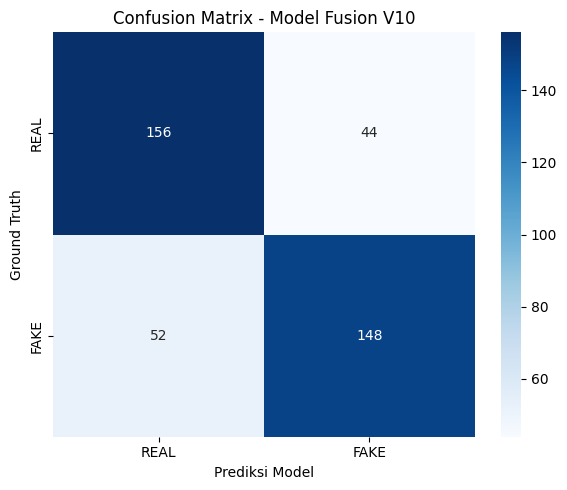


📊 CLASSIFICATION REPORT (BAB IV):

              precision    recall  f1-score   support

        REAL       0.75      0.78      0.76       200
        FAKE       0.77      0.74      0.76       200

    accuracy                           0.76       400
   macro avg       0.76      0.76      0.76       400
weighted avg       0.76      0.76      0.76       400



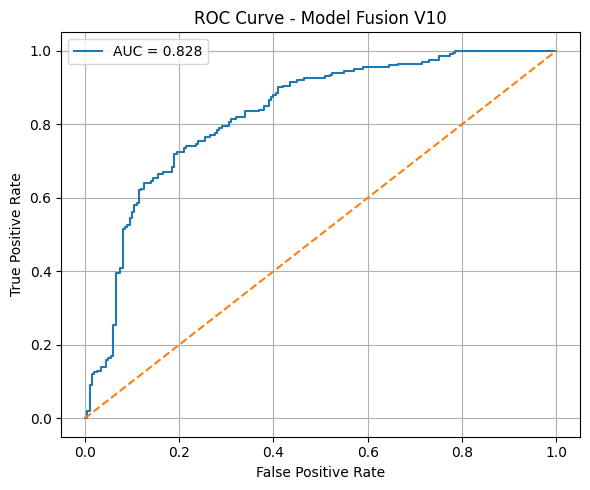

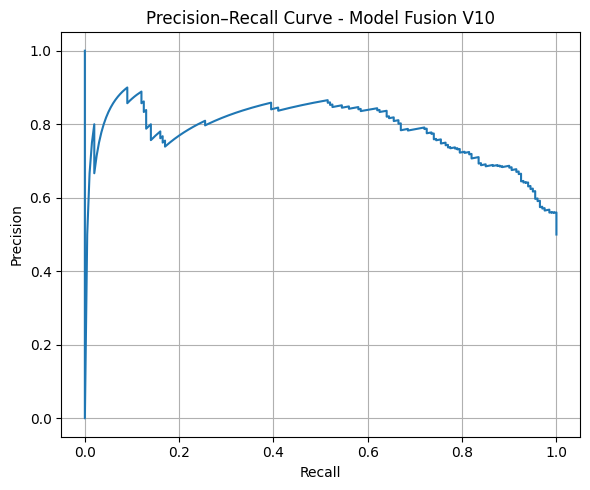

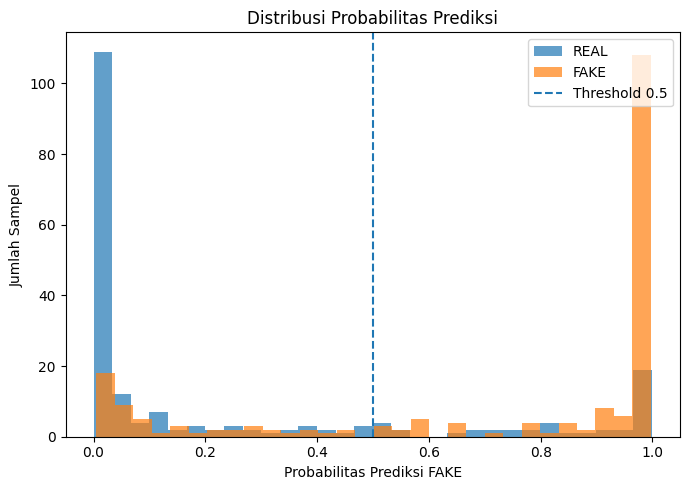


✅ SEMUA VISUALISASI BAB IV BERHASIL DIBUAT


In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.model_selection import StratifiedShuffleSplit

# ===============================
# KONFIGURASI PATH
# ===============================
OUTPUT_DRIVE_DIR = '/content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB'
MODEL_PATH = os.path.join(OUTPUT_DRIVE_DIR, 'best_model_2k_FINAL_V10.h5')
X_V_PATH = os.path.join(OUTPUT_DRIVE_DIR, 'X_visual_224.npy')
X_A_PATH = os.path.join(OUTPUT_DRIVE_DIR, 'X_audio_224.npy')
Y_PATH   = os.path.join(OUTPUT_DRIVE_DIR, 'y_224.npy')

# ===============================
# FUNGSI UTAMA BAB IV
# ===============================
def generate_all_bab4_visualizations():

    # 1️⃣ Load model
    print("🔄 Loading model...")
    model = load_model(MODEL_PATH)

    # 2️⃣ Load data (hemat RAM)
    print("📚 Loading data (memory-mapped)...")
    X_v = np.load(X_V_PATH, mmap_mode='r')
    X_a = np.load(X_A_PATH, mmap_mode='r')
    Y   = np.load(Y_PATH)

    # 3️⃣ Stratified Validation Split (20%)
    print("🧪 Stratified validation split...")
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    for _, val_idx in sss.split(np.zeros(len(Y)), Y):
        X_v_val = X_v[val_idx]
        X_a_val = X_a[val_idx]
        y_true  = Y[val_idx]

    print("Distribusi label validasi:", np.unique(y_true, return_counts=True))

    # 4️⃣ Prediksi
    print("🤖 Predicting...")
    y_prob = model.predict([X_v_val, X_a_val], batch_size=8).flatten()
    y_pred = (y_prob > 0.5).astype(int)

    # =====================================================
    # 1. CONFUSION MATRIX
    # =====================================================
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['REAL', 'FAKE'],
        yticklabels=['REAL', 'FAKE']
    )
    plt.title('Confusion Matrix - Model Fusion V10')
    plt.xlabel('Prediksi Model')
    plt.ylabel('Ground Truth')
    plt.tight_layout()
    plt.show()

    # =====================================================
    # 2. CLASSIFICATION REPORT (TABEL BAB IV)
    # =====================================================
    print("\n📊 CLASSIFICATION REPORT (BAB IV):\n")
    print(classification_report(y_true, y_pred, target_names=['REAL', 'FAKE']))

    # =====================================================
    # 3. ROC CURVE + AUC
    # =====================================================
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Model Fusion V10')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # =====================================================
    # 4. PRECISION–RECALL CURVE
    # =====================================================
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision–Recall Curve - Model Fusion V10')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # =====================================================
    # 5. DISTRIBUSI PROBABILITAS PREDIKSI
    # =====================================================
    plt.figure(figsize=(7, 5))
    plt.hist(y_prob[y_true == 0], bins=30, alpha=0.7, label='REAL')
    plt.hist(y_prob[y_true == 1], bins=30, alpha=0.7, label='FAKE')
    plt.axvline(0.5, linestyle='--', label='Threshold 0.5')
    plt.xlabel('Probabilitas Prediksi FAKE')
    plt.ylabel('Jumlah Sampel')
    plt.title('Distribusi Probabilitas Prediksi')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n✅ SEMUA VISUALISASI BAB IV BERHASIL DIBUAT")

# ===============================
# JALANKAN
# ===============================
generate_all_bab4_visualizations()


LIBRARY UNTUK MODEL V10 TERBARU

In [ ]:
!pip install -q tensorflow==2.15.0
!pip install -q mtcnn opencv-python-headless librosa seaborn scikit-learn
!pip install -q matplotlib tqdm


MODEL V10 TERBARU

📚 Memuat data dari Drive (mmap mode)...
✂️ Splitting Data...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 63, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 20, 224,   │          0 │ -                 │
│ (InputLayer)        │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 63, 13)    │          0 │ input_layer_3[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 20, 224,   │          0 │ input_layer[0][0] │
│ (TimeDistributed)   │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 63, 32)    │      1,280 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 20, 2048)  │ 20,861,480 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 31, 32)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 2048)  │      8,192 │ time_distributed… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 31, 64)    │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 128)       │    836,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv1d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,734,249 (82.91 MB)

 Trainable params: 8,195,049 (31.26 MB)

 Non-trainable params: 13,539,200 (51.65 MB)


[3/5] 🚀 START TRAINING V10 (FINAL)...
Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.4999 - loss: 12.8071
Epoch 1: val_accuracy improved from -inf to 0.49750, saving model to /content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB/best_model_2k_FINAL_V10_Revisi.weights.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 217s 475ms/step - accuracy: 0.5000 - loss: 12.7905 - val_accuracy: 0.4975 - val_loss: 2.5062 - learning_rate: 1.0000e-04
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.5078 - loss: 4.4829
Epoch 2: val_accuracy improved from 0.49750 to 0.60750, saving model to /content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB/best_model_2k_FINAL_V10_Revisi.weights.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 60s 299ms/step - accuracy: 0.5079 - loss: 4.4797 - val_accuracy: 0.6075 - val_loss: 2.1411 - learning_rate: 1.0000e-04
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.5514 - loss: 2.7951
Epoch 3: val_accuracy did not improve from 0.60750
200/

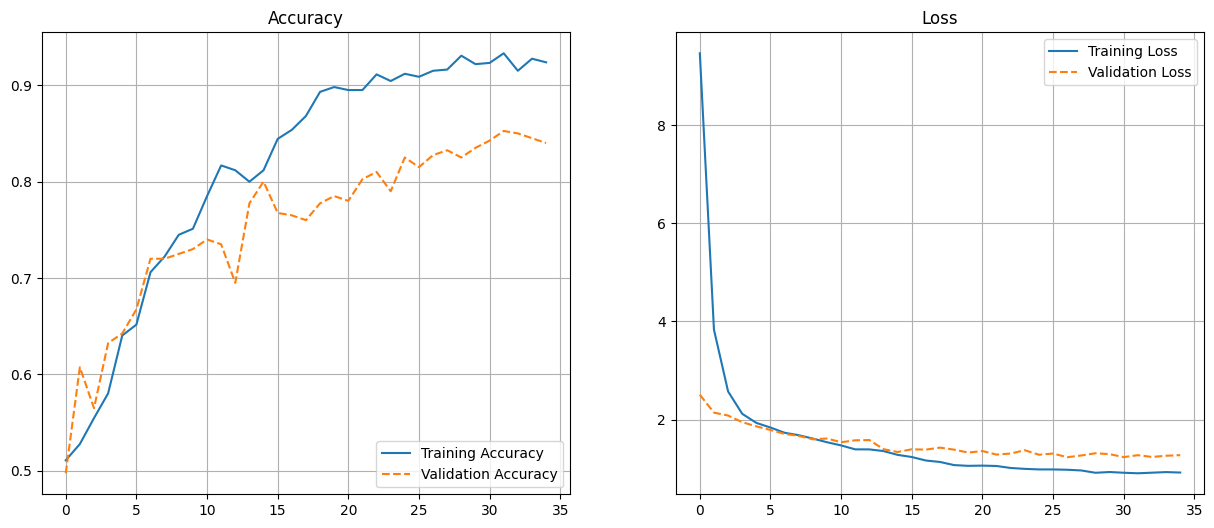

✅ Bobot Model berhasil disimpan di: /content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB/best_model_2k_FINAL_V10_Revisi.weights.h5


In [ ]:
# --- BLOK 3 (FINAL FIX V2): TRAINING + AUGMENTATION + SAVE FIX ---
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, mixed_precision, regularizers
from tensorflow.keras.applications import Xception
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import gc

# 1. SETUP & LOAD DATA
tf.keras.backend.clear_session()
mixed_precision.set_global_policy('mixed_float16')

# Path
OUTPUT_DRIVE_DIR = '/content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB'
FINAL_X_V = os.path.join(OUTPUT_DRIVE_DIR, 'X_visual_224.npy')
FINAL_X_A = os.path.join(OUTPUT_DRIVE_DIR, 'X_audio_224.npy')
FINAL_Y = os.path.join(OUTPUT_DRIVE_DIR, 'y_224.npy')

# --- PERBAIKAN DI SINI ---
# Keras mewajibkan akhiran ".weights.h5" jika save_weights_only=True
MODEL_SAVE_PATH = os.path.join(OUTPUT_DRIVE_DIR, 'best_model_2k_FINAL_V10_Revisi.weights.h5')

if not os.path.exists(FINAL_Y):
    raise FileNotFoundError("❌ File NPY belum ditemukan di Drive.")

print("📚 Memuat data dari Drive (mmap mode)...")
X_v = np.load(FINAL_X_V, mmap_mode='r')
X_a = np.load(FINAL_X_A, mmap_mode='r')
Y = np.load(FINAL_Y)

# 2. SPLIT DATA
print("✂️ Splitting Data...")
X_v_train, X_v_val, X_a_train, X_a_val, y_train, y_val = train_test_split(
    X_v, X_a, Y, test_size=0.2, random_state=42, stratify=Y
)

del X_v, X_a, Y
gc.collect()

# 3. ARSITEKTUR MODEL V10 (IMPROVED - ANTI OVERFITTING)
SEQ_LEN, IMG_SIZE, AUD_LEN = 20, 224, 63

def build_v10_improved():
    # A. DATA AUGMENTATION
    data_augmentation = models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1)
    ], name="visual_augmentation")

    # B. VISUAL STREAM
    vin = layers.Input((SEQ_LEN, IMG_SIZE, IMG_SIZE, 3))
    x = layers.TimeDistributed(data_augmentation)(vin)

    base_cnn = Xception(weights='imagenet', include_top=False, pooling='avg')
    base_cnn.trainable = True
    for layer in base_cnn.layers[:-20]:
        layer.trainable = False

    x = layers.TimeDistributed(base_cnn)(x)
    x = layers.BatchNormalization()(x)
    x = layers.GRU(128, dropout=0.5, kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.4)(x)

    # C. AUDIO STREAM
    ain = layers.Input((AUD_LEN, 13))
    y = layers.GaussianNoise(0.1)(ain)
    y = layers.Conv1D(32, 3, activation='relu', padding='same')(y)
    y = layers.MaxPooling1D(2)(y)
    y = layers.Conv1D(64, 3, activation='relu', padding='same')(y)
    y = layers.GlobalAveragePooling1D()(y)
    y = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(y)
    y = layers.Dropout(0.4)(y)

    # D. FUSION
    z = layers.concatenate([x, y])
    z = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(z)
    z = layers.Dropout(0.5)(z)
    out = layers.Dense(1, activation='sigmoid', dtype='float32')(z)

    return models.Model([vin, ain], out)

model = build_v10_improved()
model.compile(optimizer=optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# 4. TRAINING
print("\n[3/5] 🚀 START TRAINING V10 (FINAL)...")
BATCH_SIZE = 8

cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),

    # PERBAIKAN: Filename sudah .weights.h5, jadi ini akan BERHASIL
    callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

history = model.fit(
    x=[X_v_train, X_a_train], y=y_train,
    validation_data=([X_v_val, X_a_val], y_val),
    epochs=40,
    batch_size=BATCH_SIZE,
    callbacks=cb, verbose=1
)

# 5. VISUALISASI
print("\n📊 Menampilkan Grafik Hasil Training...")
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

plot_history(history)
print(f"✅ Bobot Model berhasil disimpan di: {MODEL_SAVE_PATH}")

PREDIKSI REAL VIDEO

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.15.0
✅ Model V10 berhasil dimuat TANPA ERROR


Saving bixvunsrsj.mp4 to bixvunsrsj.mp4

🔍 Menguji video: bixvunsrsj.mp4
HASIL      : REAL (Asli)
CONFIDENCE : 99.72%


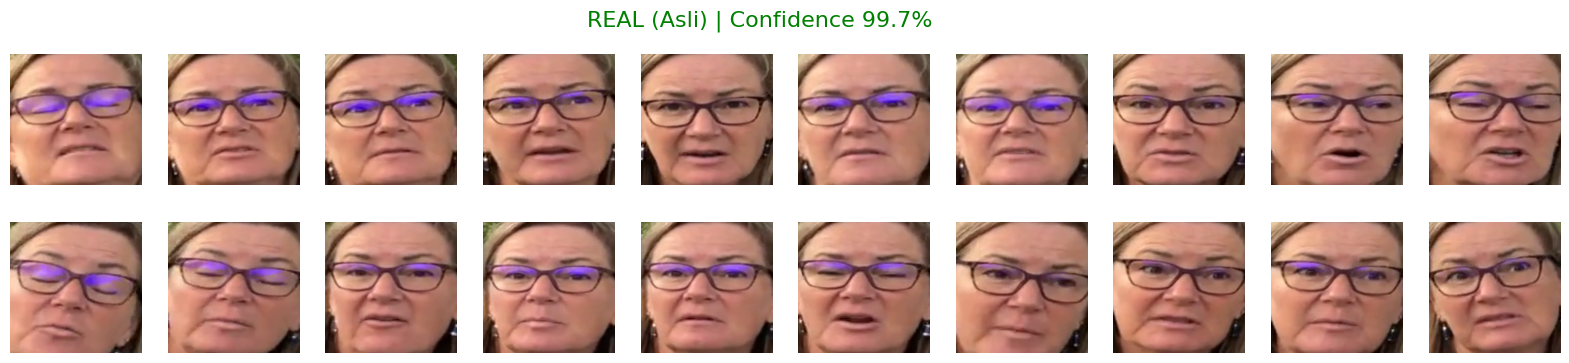


✅ PENGUJIAN VIDEO SELESAI


In [ ]:
# ============================================================
# === FINAL ALL-IN-ONE CELL (MODEL V10 TERBARU) ===
# ============================================================

# -----------------------------
# 0. INSTALL LIBRARY (AUTO)
# -----------------------------
!pip install -q tensorflow==2.15.0
!pip install -q mtcnn opencv-python-headless librosa matplotlib tqdm

# -----------------------------
# 1. IMPORT
# -----------------------------
import os, cv2, warnings
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import Xception
from google.colab import drive, files
from mtcnn import MTCNN
import librosa

# -----------------------------
# 2. SETUP
# -----------------------------
tf.keras.backend.clear_session()
tf.keras.mixed_precision.set_global_policy('mixed_float16')

SEQ_LEN = 20
IMG_SIZE = 224
AUD_LEN = 63

OUTPUT_DIR = '/content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB'
MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    'best_model_2k_FINAL_V10_Revisi.weights.h5'
)

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

detector = MTCNN()

# -----------------------------
# 3. MODEL (IDENTIK DENGAN TRAINING)
# -----------------------------
def build_v10_improved():
    data_aug = models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1)
    ])

    vin = layers.Input((SEQ_LEN, IMG_SIZE, IMG_SIZE, 3))
    x = layers.TimeDistributed(data_aug)(vin)

    base = Xception(weights='imagenet', include_top=False, pooling='avg')
    for layer in base.layers[:-20]:
        layer.trainable = False

    x = layers.TimeDistributed(base)(x)
    x = layers.BatchNormalization()(x)
    x = layers.GRU(128, dropout=0.5,
                   kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.4)(x)

    ain = layers.Input((AUD_LEN, 13))
    y = layers.GaussianNoise(0.1)(ain)
    y = layers.Conv1D(32, 3, activation='relu', padding='same')(y)
    y = layers.MaxPooling1D(2)(y)
    y = layers.Conv1D(64, 3, activation='relu', padding='same')(y)
    y = layers.GlobalAveragePooling1D()(y)
    y = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(y)
    y = layers.Dropout(0.4)(y)

    z = layers.concatenate([x, y])
    z = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01))(z)
    z = layers.Dropout(0.5)(z)

    out = layers.Dense(1, activation='sigmoid', dtype='float32')(z)
    return models.Model([vin, ain], out)

# -----------------------------
# 4. LOAD MODEL
# -----------------------------
model = build_v10_improved()
model.load_weights(MODEL_PATH)
print("✅ Model V10 berhasil dimuat TANPA ERROR")

# -----------------------------
# 5. FUNGSI PREPROCESS VIDEO
# -----------------------------
def variance_of_laplacian(img):
    return cv2.Laplacian(img, cv2.CV_64F).var()

def extract_audio(path):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        y, sr = librosa.load(path, sr=16000, duration=3)
        mfcc = librosa.feature.mfcc(y=y, sr=16000, n_mfcc=13).T
        if mfcc.shape[0] < AUD_LEN:
            mfcc = np.pad(mfcc, ((0, AUD_LEN-mfcc.shape[0]), (0,0)))
        return mfcc[:AUD_LEN].astype(np.float32)

def preprocess_video(path):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < SEQ_LEN:
        return None, None, None

    step = total // SEQ_LEN
    frames_proc, frames_show = [], []

    for i in range(SEQ_LEN):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        best, sharp = None, -1

        for _ in range(step):
            ret, frame = cap.read()
            if not ret: break
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            s = variance_of_laplacian(gray)
            if s > sharp:
                sharp = s
                best = frame

        if best is not None:
            rgb = cv2.cvtColor(best, cv2.COLOR_BGR2RGB)
            res = detector.detect_faces(rgb)
            if res:
                x,y,w,h = res[0]['box']
                face = rgb[y:y+h, x:x+w]
                try:
                    face_r = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
                    frames_proc.append(face_r / 255.0)
                    frames_show.append(face_r)
                except:
                    pass

    cap.release()
    if len(frames_proc) < SEQ_LEN:
        return None, None, None

    return (
        np.array(frames_proc[:SEQ_LEN], dtype=np.float32),
        extract_audio(path),
        frames_show[:SEQ_LEN]
    )

# -----------------------------
# 6. UPLOAD & PREDIKSI
# -----------------------------
uploaded = files.upload()

for f in uploaded:
    print(f"\n🔍 Menguji video: {f}")
    vis, aud, frames = preprocess_video(f)

    if vis is None:
        print("❌ Gagal memproses video")
        continue

    pred = model.predict(
        [vis[np.newaxis], aud[np.newaxis]],
        verbose=0
    )[0][0]

    label = "FAKE (Deepfake)" if pred > 0.5 else "REAL (Asli)"
    conf = pred if pred > 0.5 else 1 - pred

    print("="*50)
    print(f"HASIL      : {label}")
    print(f"CONFIDENCE : {conf*100:.2f}%")
    print("="*50)

    # -------------------------
    # 7. VISUALISASI 20 FRAME
    # -------------------------
    plt.figure(figsize=(20, 4))
    plt.suptitle(
        f"{label} | Confidence {conf*100:.1f}%",
        fontsize=16,
        color='red' if pred > 0.5 else 'green'
    )

    for i in range(20):
        plt.subplot(2, 10, i+1)
        plt.imshow(frames[i])
        plt.axis('off')

    plt.show()

    os.remove(f)

print("\n✅ PENGUJIAN VIDEO SELESAI")


PREDIKSI FAKE VIDEO

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.15.0
✅ Model V10 berhasil dimuat TANPA ERROR


Saving DFDC_bfokutsmfl.mp4 to DFDC_bfokutsmfl.mp4

🔍 Menguji video: DFDC_bfokutsmfl.mp4
HASIL      : FAKE (Deepfake)
CONFIDENCE : 99.28%


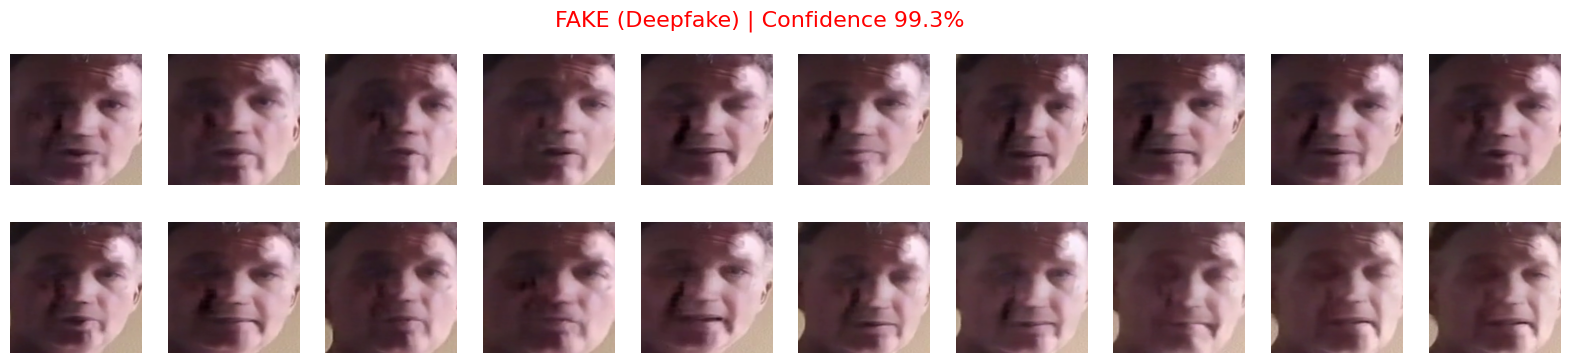


✅ PENGUJIAN VIDEO SELESAI


In [ ]:
# ============================================================
# === FINAL ALL-IN-ONE CELL (MODEL V10 TERBARU) ===
# ============================================================

# -----------------------------
# 0. INSTALL LIBRARY (AUTO)
# -----------------------------
!pip install -q tensorflow==2.15.0
!pip install -q mtcnn opencv-python-headless librosa matplotlib tqdm

# -----------------------------
# 1. IMPORT
# -----------------------------
import os, cv2, warnings
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import Xception
from google.colab import drive, files
from mtcnn import MTCNN
import librosa

# -----------------------------
# 2. SETUP
# -----------------------------
tf.keras.backend.clear_session()
tf.keras.mixed_precision.set_global_policy('mixed_float16')

SEQ_LEN = 20
IMG_SIZE = 224
AUD_LEN = 63

OUTPUT_DIR = '/content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB'
MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    'best_model_2k_FINAL_V10_Revisi.weights.h5'
)

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

detector = MTCNN()

# -----------------------------
# 3. MODEL (IDENTIK DENGAN TRAINING)
# -----------------------------
def build_v10_improved():
    data_aug = models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1)
    ])

    vin = layers.Input((SEQ_LEN, IMG_SIZE, IMG_SIZE, 3))
    x = layers.TimeDistributed(data_aug)(vin)

    base = Xception(weights='imagenet', include_top=False, pooling='avg')
    for layer in base.layers[:-20]:
        layer.trainable = False

    x = layers.TimeDistributed(base)(x)
    x = layers.BatchNormalization()(x)
    x = layers.GRU(128, dropout=0.5,
                   kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.4)(x)

    ain = layers.Input((AUD_LEN, 13))
    y = layers.GaussianNoise(0.1)(ain)
    y = layers.Conv1D(32, 3, activation='relu', padding='same')(y)
    y = layers.MaxPooling1D(2)(y)
    y = layers.Conv1D(64, 3, activation='relu', padding='same')(y)
    y = layers.GlobalAveragePooling1D()(y)
    y = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(y)
    y = layers.Dropout(0.4)(y)

    z = layers.concatenate([x, y])
    z = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01))(z)
    z = layers.Dropout(0.5)(z)

    out = layers.Dense(1, activation='sigmoid', dtype='float32')(z)
    return models.Model([vin, ain], out)

# -----------------------------
# 4. LOAD MODEL
# -----------------------------
model = build_v10_improved()
model.load_weights(MODEL_PATH)
print("✅ Model V10 berhasil dimuat TANPA ERROR")

# -----------------------------
# 5. FUNGSI PREPROCESS VIDEO
# -----------------------------
def variance_of_laplacian(img):
    return cv2.Laplacian(img, cv2.CV_64F).var()

def extract_audio(path):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        y, sr = librosa.load(path, sr=16000, duration=3)
        mfcc = librosa.feature.mfcc(y=y, sr=16000, n_mfcc=13).T
        if mfcc.shape[0] < AUD_LEN:
            mfcc = np.pad(mfcc, ((0, AUD_LEN-mfcc.shape[0]), (0,0)))
        return mfcc[:AUD_LEN].astype(np.float32)

def preprocess_video(path):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < SEQ_LEN:
        return None, None, None

    step = total // SEQ_LEN
    frames_proc, frames_show = [], []

    for i in range(SEQ_LEN):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        best, sharp = None, -1

        for _ in range(step):
            ret, frame = cap.read()
            if not ret: break
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            s = variance_of_laplacian(gray)
            if s > sharp:
                sharp = s
                best = frame

        if best is not None:
            rgb = cv2.cvtColor(best, cv2.COLOR_BGR2RGB)
            res = detector.detect_faces(rgb)
            if res:
                x,y,w,h = res[0]['box']
                face = rgb[y:y+h, x:x+w]
                try:
                    face_r = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
                    frames_proc.append(face_r / 255.0)
                    frames_show.append(face_r)
                except:
                    pass

    cap.release()
    if len(frames_proc) < SEQ_LEN:
        return None, None, None

    return (
        np.array(frames_proc[:SEQ_LEN], dtype=np.float32),
        extract_audio(path),
        frames_show[:SEQ_LEN]
    )

# -----------------------------
# 6. UPLOAD & PREDIKSI
# -----------------------------
uploaded = files.upload()

for f in uploaded:
    print(f"\n🔍 Menguji video: {f}")
    vis, aud, frames = preprocess_video(f)

    if vis is None:
        print("❌ Gagal memproses video")
        continue

    pred = model.predict(
        [vis[np.newaxis], aud[np.newaxis]],
        verbose=0
    )[0][0]

    label = "FAKE (Deepfake)" if pred > 0.5 else "REAL (Asli)"
    conf = pred if pred > 0.5 else 1 - pred

    print("="*50)
    print(f"HASIL      : {label}")
    print(f"CONFIDENCE : {conf*100:.2f}%")
    print("="*50)

    # -------------------------
    # 7. VISUALISASI 20 FRAME
    # -------------------------
    plt.figure(figsize=(20, 4))
    plt.suptitle(
        f"{label} | Confidence {conf*100:.1f}%",
        fontsize=16,
        color='red' if pred > 0.5 else 'green'
    )

    for i in range(20):
        plt.subplot(2, 10, i+1)
        plt.imshow(frames[i])
        plt.axis('off')

    plt.show()

    os.remove(f)

print("\n✅ PENGUJIAN VIDEO SELESAI")


In [ ]:
# --- BLOK 3.5: LOAD DATA & SPLIT ULANG UNTUK EVALUASI ---

import os
import numpy as np
import gc
from sklearn.model_selection import train_test_split

OUTPUT_DRIVE_DIR = '/content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB'

FINAL_X_V = os.path.join(OUTPUT_DRIVE_DIR, 'X_visual_224.npy')
FINAL_X_A = os.path.join(OUTPUT_DRIVE_DIR, 'X_audio_224.npy')
FINAL_Y   = os.path.join(OUTPUT_DRIVE_DIR, 'y_224.npy')

print("📚 Load data dari Drive (evaluation mode)...")

X_v = np.load(FINAL_X_V, mmap_mode='r')
X_a = np.load(FINAL_X_A, mmap_mode='r')
Y   = np.load(FINAL_Y)

print("✂️ Split data (same setting as training)...")

X_v_train, X_v_val, X_a_train, X_a_val, y_train, y_val = train_test_split(
    X_v, X_a, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

del X_v, X_a, Y
gc.collect()

print("✅ Data validation siap dipakai")


📚 Load data dari Drive (evaluation mode)...
✂️ Split data (same setting as training)...
✅ Data validation siap dipakai


🔍 Evaluasi model menggunakan data validation...
50/50 ━━━━━━━━━━━━━━━━━━━━ 57s 471ms/step


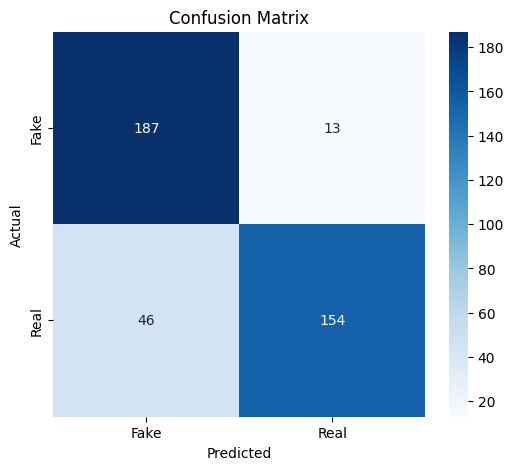


📄 Classification Report:
              precision    recall  f1-score   support

        Fake       0.80      0.94      0.86       200
        Real       0.92      0.77      0.84       200

    accuracy                           0.85       400
   macro avg       0.86      0.85      0.85       400
weighted avg       0.86      0.85      0.85       400



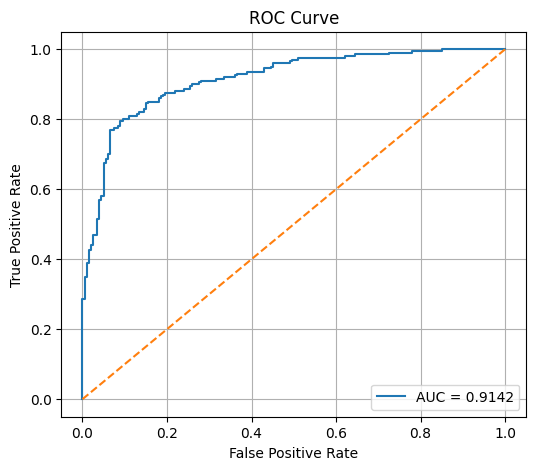

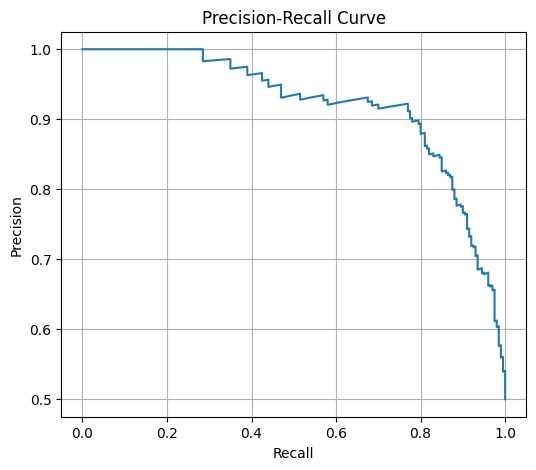

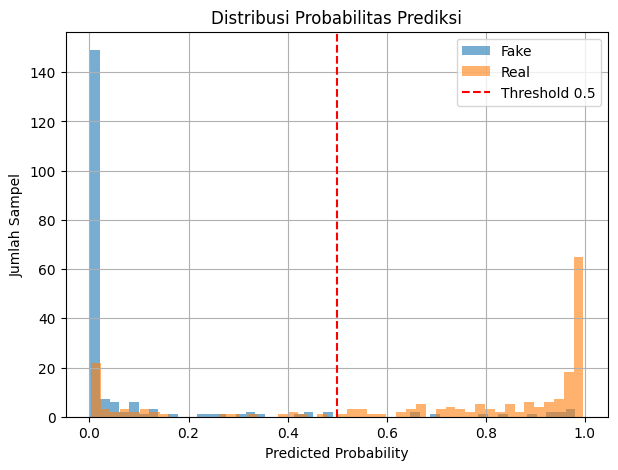

✅ AUC ROC: 0.9142


In [ ]:
# --- BLOK 4: EVALUASI & VISUALISASI MODEL ---

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

# PATH MODEL
OUTPUT_DRIVE_DIR = '/content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB'
MODEL_SAVE_PATH = os.path.join(
    OUTPUT_DRIVE_DIR,
    'best_model_2k_FINAL_V10_Revisi.weights.h5'
)

print("🔍 Evaluasi model menggunakan data validation...")

# LOAD BEST WEIGHTS
model.load_weights(MODEL_SAVE_PATH)

# PREDIKSI
y_prob = model.predict([X_v_val, X_a_val], batch_size=8)
y_pred = (y_prob >= 0.5).astype(int)

# CONFUSION MATRIX
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# CLASSIFICATION REPORT
print("\n📄 Classification Report:")
print(classification_report(
    y_val, y_pred,
    target_names=["Fake", "Real"]
))

# ROC CURVE
fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# PRECISION-RECALL CURVE
precision, recall, _ = precision_recall_curve(y_val, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

# DISTRIBUSI PROBABILITAS
plt.figure(figsize=(7, 5))
plt.hist(y_prob[y_val == 0], bins=50, alpha=0.6, label="Fake")
plt.hist(y_prob[y_val == 1], bins=50, alpha=0.6, label="Real")
plt.axvline(0.5, color="red", linestyle="--", label="Threshold 0.5")
plt.xlabel("Predicted Probability")
plt.ylabel("Jumlah Sampel")
plt.title("Distribusi Probabilitas Prediksi")
plt.legend()
plt.grid(True)
plt.show()

print(f"✅ AUC ROC: {roc_auc:.4f}")


SIMPAN KE .KERAS

In [ ]:
# =====================================================
# FULL SCRIPT: LOAD WEIGHTS + SAVE MODEL KE .keras
# TANPA TRAINING ULANG (FINAL & AMAN)
# =====================================================

import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, mixed_precision
from tensorflow.keras.applications import Xception

# ===============================
# 1. SETUP
# ===============================
tf.keras.backend.clear_session()
mixed_precision.set_global_policy('mixed_float16')

OUTPUT_DRIVE_DIR = '/content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB'

WEIGHTS_PATH = os.path.join(
    OUTPUT_DRIVE_DIR,
    'best_model_2k_FINAL_V10_Revisi.weights.h5'
)

KERAS_MODEL_PATH = os.path.join(
    OUTPUT_DRIVE_DIR,
    'best_model_2k_FINAL_V10_Revisi.keras'
)

# ===============================
# 2. KONSTANTA (HARUS SAMA)
# ===============================
SEQ_LEN = 20
IMG_SIZE = 224
AUD_LEN = 63

# ===============================
# 3. BUILD MODEL (IDENTIK DENGAN TRAINING)
# ===============================
def build_v10_improved():
    # A. DATA AUGMENTATION
    data_augmentation = models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1)
    ], name="visual_augmentation")

    # B. VISUAL STREAM
    vin = layers.Input((SEQ_LEN, IMG_SIZE, IMG_SIZE, 3), name="visual_input")
    x = layers.TimeDistributed(data_augmentation)(vin)

    base_cnn = Xception(weights='imagenet', include_top=False, pooling='avg')
    base_cnn.trainable = True
    for layer in base_cnn.layers[:-20]:
        layer.trainable = False

    x = layers.TimeDistributed(base_cnn)(x)
    x = layers.BatchNormalization()(x)
    x = layers.GRU(128, dropout=0.5,
                  kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.4)(x)

    # C. AUDIO STREAM
    ain = layers.Input((AUD_LEN, 13), name="audio_input")
    y = layers.GaussianNoise(0.1)(ain)
    y = layers.Conv1D(32, 3, activation='relu', padding='same')(y)
    y = layers.MaxPooling1D(2)(y)
    y = layers.Conv1D(64, 3, activation='relu', padding='same')(y)
    y = layers.GlobalAveragePooling1D()(y)
    y = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(y)
    y = layers.Dropout(0.4)(y)

    # D. FUSION
    z = layers.concatenate([x, y])
    z = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01))(z)
    z = layers.Dropout(0.5)(z)

    out = layers.Dense(1, activation='sigmoid',
                       dtype='float32', name="output")(z)

    return models.Model([vin, ain], out)

# ===============================
# 4. INIT MODEL
# ===============================
print("🧠 Membangun arsitektur model...")
model = build_v10_improved()
print("✅ Model siap")

# ===============================
# 5. LOAD TRAINED WEIGHTS
# ===============================
print("🔄 Loading trained weights...")
model.load_weights(WEIGHTS_PATH)
print("✅ Weights berhasil dimuat")

# ===============================
# 6. SAVE FULL MODEL KE .keras
# ===============================
print("💾 Menyimpan model ke format .keras...")
model.save(KERAS_MODEL_PATH)
print(f"✅ Model berhasil disimpan ke: {KERAS_MODEL_PATH}")

# ===============================
# 7. VERIFIKASI
# ===============================
print("🔍 Verifikasi model...")
loaded_model = tf.keras.models.load_model(KERAS_MODEL_PATH)
loaded_model.summary()

print("🎉 SELESAI — TANPA TRAINING ULANG, TANPA ERROR")


🧠 Membangun arsitektur model...
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✅ Model siap
🔄 Loading trained weights...
✅ Weights berhasil dimuat
💾 Menyimpan model ke format .keras...
✅ Model berhasil disimpan ke: /content/drive/MyDrive/SKRIPSI33/PROCESSED_DATA_FINAL_23GB/best_model_2k_FINAL_V10_Revisi.keras
🔍 Verifikasi model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_input         │ (None, 63, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visual_input        │ (None, 20, 224,   │          0 │ -                 │
│ (InputLayer)        │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 63, 13)    │          0 │ audio_input[0][0] │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 20, 224,   │          0 │ visual_input[0][… │
│ (TimeDistributed)   │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 63, 32)    │      1,280 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 20, 2048)  │ 20,861,480 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 31, 32)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 2048)  │      8,192 │ time_distributed… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 31, 64)    │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 128)       │    836,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv1d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,734,249 (82.91 MB)

 Trainable params: 8,195,049 (31.26 MB)

 Non-trainable params: 13,539,200 (51.65 MB)

🎉 SELESAI — TANPA TRAINING ULANG, TANPA ERROR
